In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

print("\nPlantVision environment is ready!")

OpenCV: 5.0.0
NumPy: 2.5.1
Pandas: 3.0.5
Scikit-learn: 1.9.0

PlantVision environment is ready!


In [2]:
from pathlib import Path

# Path from notebooks/ to the dataset
DATASET_PATH = Path("../data/raw/PlantVillage/color")

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())

Dataset path: ..\data\raw\PlantVillage\color
Dataset exists: True


In [3]:
class_folders = sorted([
    folder for folder in DATASET_PATH.iterdir()
    if folder.is_dir()
])

print("Total number of classes:", len(class_folders))

for folder in class_folders:
    print(folder.name)

Total number of classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___healthy
Strawberry___Leaf_scorch
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf

In [4]:
import pandas as pd

data = []

valid_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

for class_folder in class_folders:

    class_name = class_folder.name

    # PlantVillage class names are generally Plant___Disease
    if "___" in class_name:
        plant, disease = class_name.split("___", 1)
    else:
        plant = class_name
        disease = "Unknown"

    for image_path in class_folder.iterdir():

        if image_path.suffix in valid_extensions:

            data.append({
                "image_path": str(image_path),
                "plant": plant,
                "disease": disease,
                "class": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))

df.head()

Total images: 54762


,image_path,plant,disease,class
0,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
1,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
2,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
3,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
4,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab


In [5]:
# Count images for each plant
plant_counts = df["plant"].value_counts()

print("Number of unique plants:", df["plant"].nunique())
print("\nImages per plant:")
print(plant_counts)

Number of unique plants: 14

Images per plant:
plant
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3628
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371
Name: count, dtype: int64


In [6]:
classes_per_plant = df.groupby("plant")["class"].nunique().sort_values(ascending=False)

print("Classes per plant:")
print(classes_per_plant)

Classes per plant:
plant
Tomato                     10
Apple                       4
Grape                       4
Corn_(maize)                4
Potato                      3
Cherry_(including_sour)     2
Strawberry                  2
Peach                       2
Pepper,_bell                2
Blueberry                   1
Orange                      1
Raspberry                   1
Squash                      1
Soybean                     1
Name: class, dtype: int64


In [7]:
selected_plants = [
    "Tomato",
    "Apple",
    "Grape",
    "Corn_(maize)",
    "Potato",
    "Pepper,_bell"
]

selected_df = df[df["plant"].isin(selected_plants)].copy()

print("Original dataset:", len(df))
print("Selected dataset:", len(selected_df))
print("Number of plants:", selected_df["plant"].nunique())
print("Number of classes:", selected_df["class"].nunique())

Original dataset: 54762
Selected dataset: 34329
Number of plants: 6
Number of classes: 27


In [8]:
class_counts = selected_df["class"].value_counts().sort_index()

for class_name, count in class_counts.items():
    print(f"{class_name:<55} {count}")

Apple___Apple_scab                                      1087
Apple___Black_rot                                       621
Apple___Cedar_apple_rust                                275
Apple___healthy                                         1645
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      513
Corn_(maize)___Common_rust_                             1192
Corn_(maize)___Northern_Leaf_Blight                     985
Corn_(maize)___healthy                                  1162
Grape___Black_rot                                       1180
Grape___Esca_(Black_Measles)                            1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)              1076
Grape___healthy                                         423
Pepper,_bell___Bacterial_spot                           997
Pepper,_bell___healthy                                  1478
Potato___Early_blight                                   1000
Potato___Late_blight                                    1000
Potato___healthy              

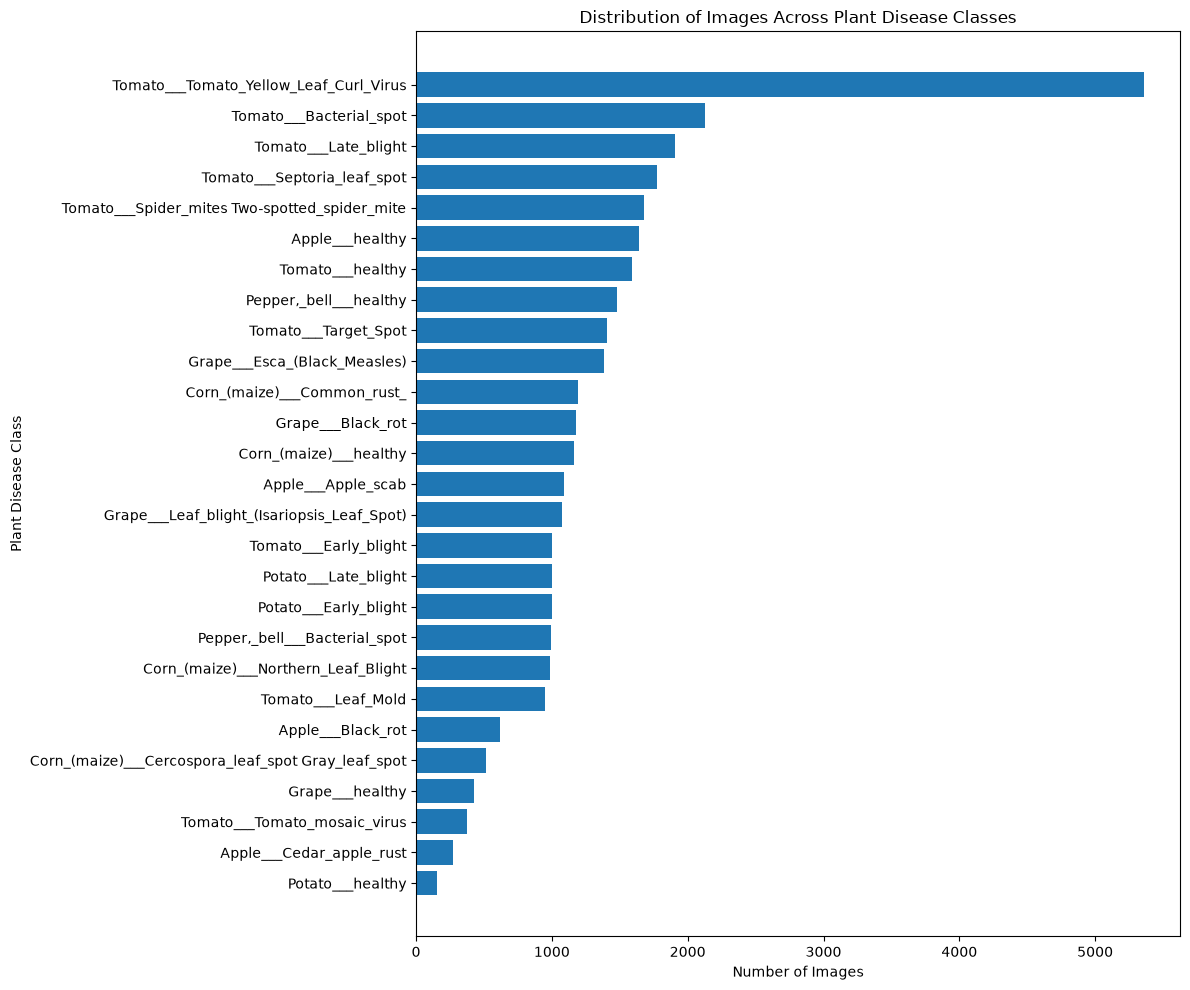

In [9]:
import matplotlib.pyplot as plt

class_counts = selected_df["class"].value_counts().sort_values()

plt.figure(figsize=(12, 10))

plt.barh(class_counts.index, class_counts.values)

plt.xlabel("Number of Images")
plt.ylabel("Plant Disease Class")
plt.title("Distribution of Images Across Plant Disease Classes")

plt.tight_layout()
plt.show()

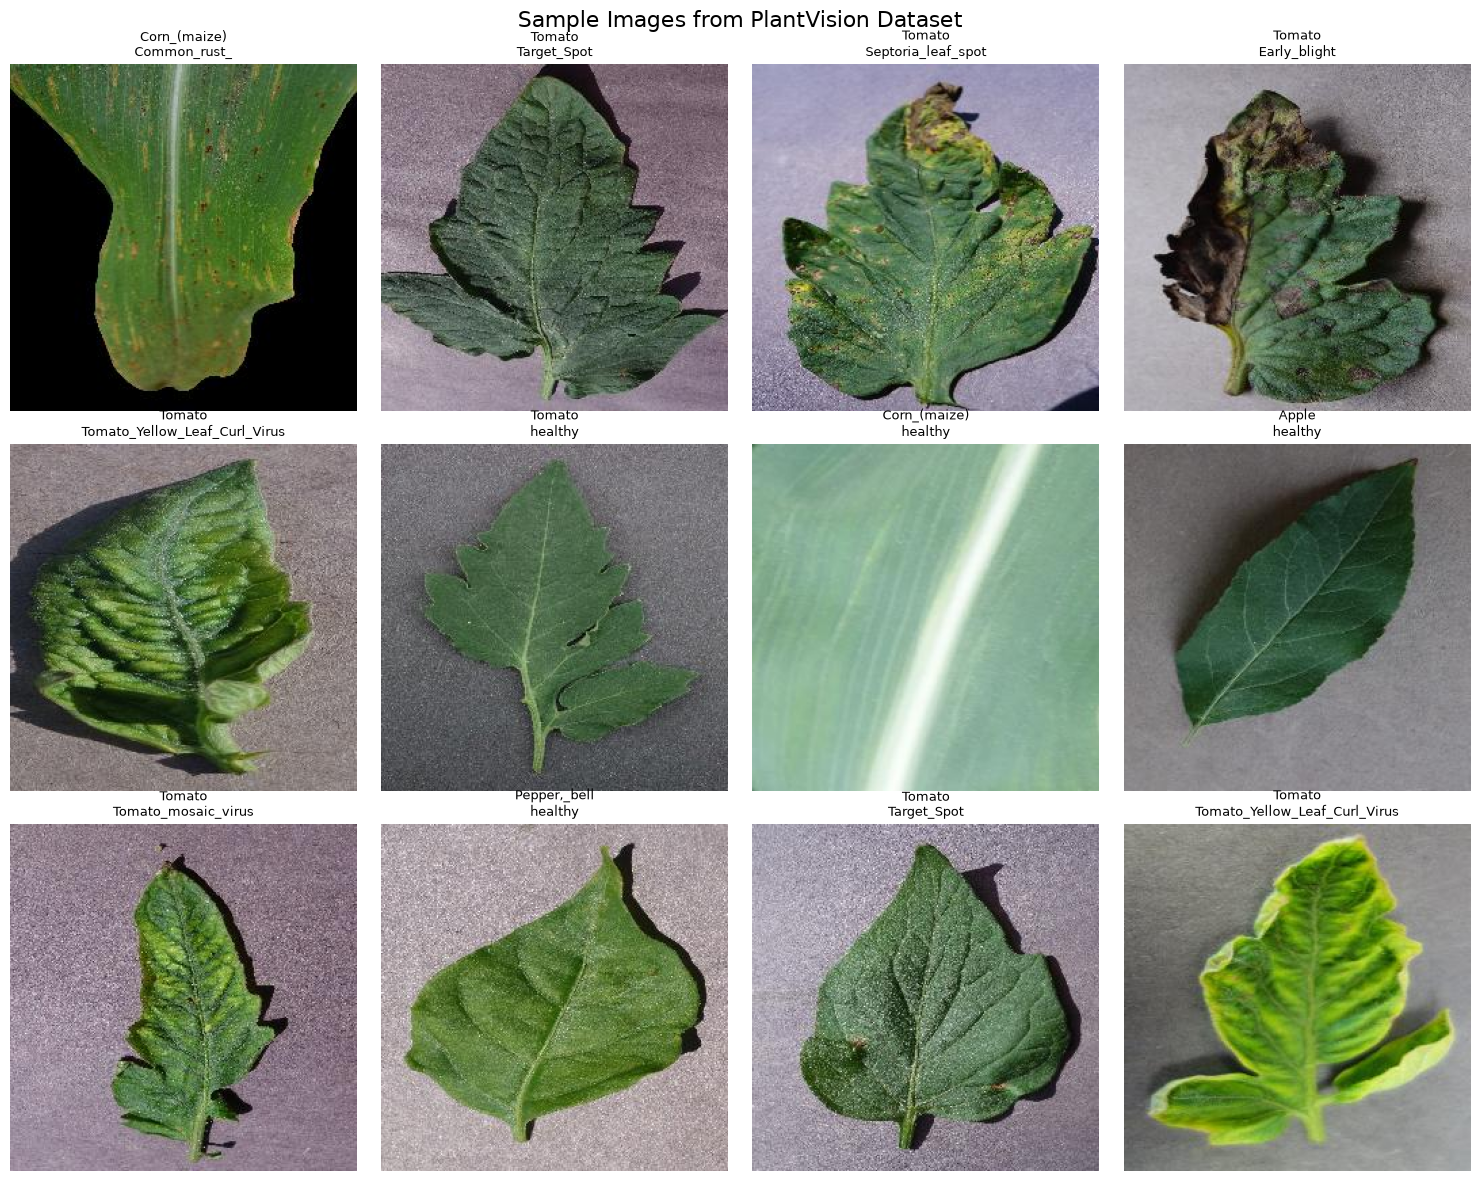

In [11]:
import cv2
import matplotlib.pyplot as plt


samples = selected_df.sample(12, random_state=42)

plt.figure(figsize=(15, 12))

for i, (_, row) in enumerate(samples.iterrows()):

    image = cv2.imread(row["image_path"])

    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)

    title = row["class"].replace("___", "\n")
    plt.title(title, fontsize=9)

    plt.axis("off")

plt.suptitle(
    "Sample Images from PlantVision Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [12]:
import cv2
from collections import Counter

image_shapes = []

for image_path in selected_df["image_path"]:
    image = cv2.imread(image_path)

    if image is not None:
        image_shapes.append(image.shape)

print("Total valid images checked:", len(image_shapes))
print("Number of unique image shapes:", len(set(image_shapes)))

print("\nMost common image shapes:")

for shape, count in Counter(image_shapes).most_common(10):
    print(shape, "→", count, "images")

Total valid images checked: 34329
Number of unique image shapes: 1

Most common image shapes:
(256, 256, 3) → 34329 images


In [13]:
corrupted_images = []

for image_path in selected_df["image_path"]:

    image = cv2.imread(image_path)

    if image is None:
        corrupted_images.append(image_path)

print("Corrupted/unreadable images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for path in corrupted_images[:10]:
        print(path)

Corrupted/unreadable images: 0


In [14]:
sample_path = selected_df.iloc[0]["image_path"]

print("Selected image:")
print(sample_path)

Selected image:
..\data\raw\PlantVillage\color\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335 (2).JPG


Original shape: (256, 256, 3)


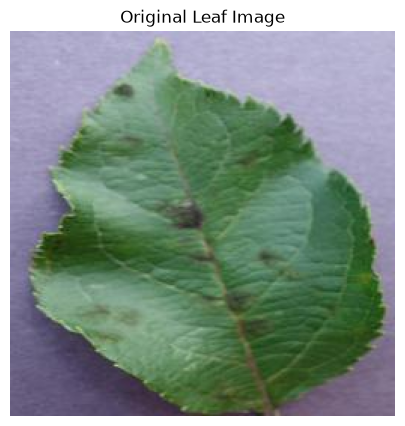

In [15]:
import cv2
import matplotlib.pyplot as plt

# Read image
image_bgr = cv2.imread(sample_path)

# Convert BGR → RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Original shape:", image_rgb.shape)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title("Original Leaf Image")
plt.axis("off")
plt.show()

Before: (256, 256, 3)
After: (224, 224, 3)


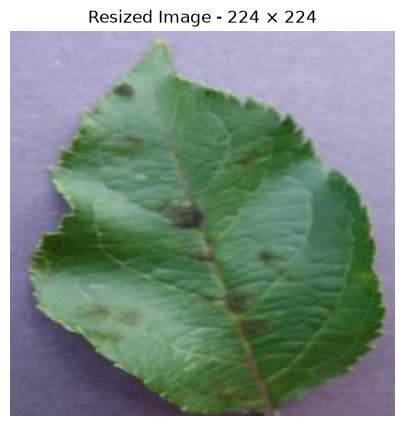

In [16]:
IMAGE_SIZE = (224, 224)

resized_image = cv2.resize(
    image_rgb,
    IMAGE_SIZE,
    interpolation=cv2.INTER_AREA
)

print("Before:", image_rgb.shape)
print("After:", resized_image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(resized_image)
plt.title("Resized Image - 224 × 224")
plt.axis("off")
plt.show()

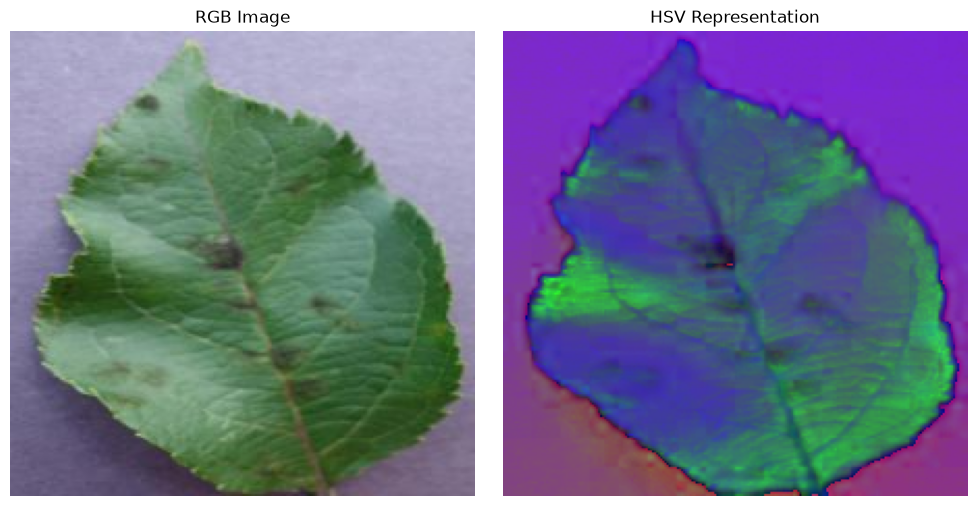

In [17]:
hsv_image = cv2.cvtColor(resized_image, cv2.COLOR_RGB2HSV)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(resized_image)
axes[0].set_title("RGB Image")
axes[0].axis("off")

axes[1].imshow(hsv_image)
axes[1].set_title("HSV Representation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

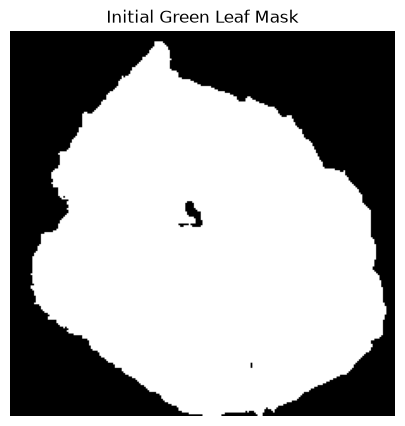

In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# HSV range for green regions
lower_green = np.array([20, 30, 20])
upper_green = np.array([100, 255, 255])

# Create binary mask
green_mask = cv2.inRange(
    hsv_image,
    lower_green,
    upper_green
)

plt.figure(figsize=(5, 5))
plt.imshow(green_mask, cmap="gray")
plt.title("Initial Green Leaf Mask")
plt.axis("off")
plt.show()

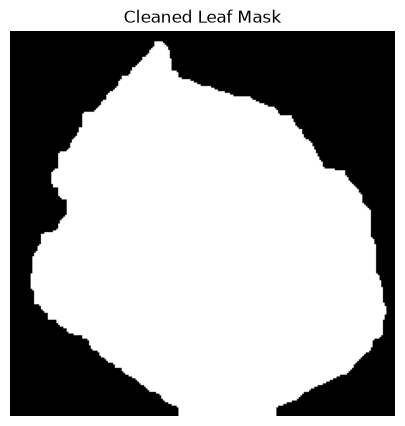

In [19]:
kernel = np.ones((5, 5), np.uint8)

clean_mask = cv2.morphologyEx(
    green_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

clean_mask = cv2.morphologyEx(
    clean_mask,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

plt.figure(figsize=(5, 5))
plt.imshow(clean_mask, cmap="gray")
plt.title("Cleaned Leaf Mask")
plt.axis("off")
plt.show()

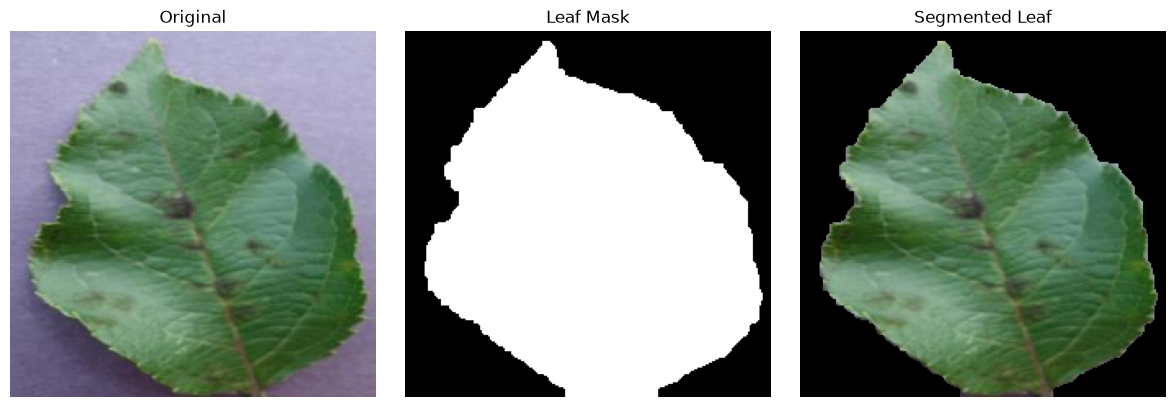

In [20]:
segmented_leaf = cv2.bitwise_and(
    resized_image,
    resized_image,
    mask=clean_mask
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(resized_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(clean_mask, cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_leaf)
plt.title("Segmented Leaf")
plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Select only the pixels that belong to the leaf
leaf_pixels_rgb = resized_image[clean_mask > 0]

print("Leaf pixels shape:", leaf_pixels_rgb.shape)
print("Total leaf pixels:", len(leaf_pixels_rgb))

Leaf pixels shape: (30240, 3)
Total leaf pixels: 30240


In [22]:
# Mean RGB values
mean_r = np.mean(leaf_pixels_rgb[:, 0])
mean_g = np.mean(leaf_pixels_rgb[:, 1])
mean_b = np.mean(leaf_pixels_rgb[:, 2])

# Standard deviation RGB
std_r = np.std(leaf_pixels_rgb[:, 0])
std_g = np.std(leaf_pixels_rgb[:, 1])
std_b = np.std(leaf_pixels_rgb[:, 2])

print("RGB Mean:")
print("R:", round(mean_r, 2))
print("G:", round(mean_g, 2))
print("B:", round(mean_b, 2))

print("\nRGB Standard Deviation:")
print("R:", round(std_r, 2))
print("G:", round(std_g, 2))
print("B:", round(std_b, 2))

RGB Mean:
R: 85.51
G: 121.7
B: 85.09

RGB Standard Deviation:
R: 28.43
G: 28.77
B: 35.64


In [23]:
hsv_image

array([[[124,  43, 196],
        [124,  43, 195],
        [124,  43, 194],
        ...,
        [123,  35, 212],
        [123,  35, 210],
        [123,  36, 207]],

       [[124,  42, 199],
        [124,  42, 198],
        [124,  43, 197],
        ...,
        [123,  35, 213],
        [123,  35, 211],
        [123,  35, 210]],

       [[124,  42, 198],
        [124,  43, 197],
        [124,  43, 196],
        ...,
        [123,  35, 214],
        [123,  35, 213],
        [123,  35, 212]],

       ...,

       [[129,  69, 125],
        [129,  68, 127],
        [129,  68, 128],
        ...,
        [138,  48, 138],
        [138,  50, 138],
        [138,  50, 138]],

       [[129,  69, 125],
        [129,  69, 126],
        [129,  68, 128],
        ...,
        [138,  51, 134],
        [138,  51, 135],
        [138,  51, 135]],

       [[129,  68, 128],
        [129,  68, 127],
        [129,  69, 126],
        ...,
        [138,  53, 131],
        [138,  52, 133],
        [138,  51, 134]]

In [24]:
leaf_pixels_hsv = hsv_image[clean_mask > 0]

mean_h = np.mean(leaf_pixels_hsv[:, 0])
mean_s = np.mean(leaf_pixels_hsv[:, 1])
mean_v = np.mean(leaf_pixels_hsv[:, 2])

std_h = np.std(leaf_pixels_hsv[:, 0])
std_s = np.std(leaf_pixels_hsv[:, 1])
std_v = np.std(leaf_pixels_hsv[:, 2])

print("HSV Mean:")
print("H:", round(mean_h, 2))
print("S:", round(mean_s, 2))
print("V:", round(mean_v, 2))

print("\nHSV Standard Deviation:")
print("H:", round(std_h, 2))
print("S:", round(std_s, 2))
print("V:", round(std_v, 2))

HSV Mean:
H: 60.08
S: 93.26
V: 121.76

HSV Standard Deviation:
H: 10.29
S: 34.62
V: 28.67


In [25]:
color_features = {
    "mean_r": mean_r,
    "mean_g": mean_g,
    "mean_b": mean_b,

    "std_r": std_r,
    "std_g": std_g,
    "std_b": std_b,

    "mean_h": mean_h,
    "mean_s": mean_s,
    "mean_v": mean_v,

    "std_h": std_h,
    "std_s": std_s,
    "std_v": std_v
}

color_features

{'mean_r': np.float64(85.50780423280423),
 'mean_g': np.float64(121.69679232804233),
 'mean_b': np.float64(85.09494047619047),
 'std_r': np.float64(28.42690207963705),
 'std_g': np.float64(28.772631355294326),
 'std_b': np.float64(35.644674287879944),
 'mean_h': np.float64(60.08399470899471),
 'mean_s': np.float64(93.26104497354497),
 'mean_v': np.float64(121.76421957671958),
 'std_h': np.float64(10.293886968003141),
 'std_s': np.float64(34.61789786911222),
 'std_v': np.float64(28.67370534987532)}

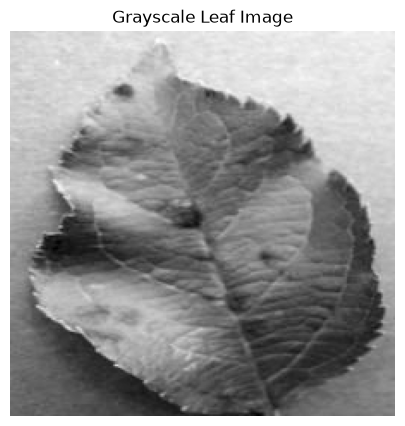

In [26]:
from skimage.feature import graycomatrix, graycoprops

gray_image = cv2.cvtColor(resized_image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Leaf Image")
plt.axis("off")
plt.show()

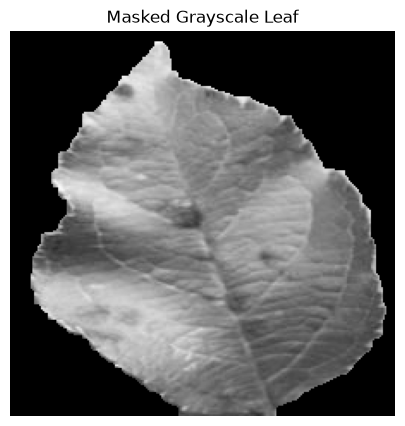

In [27]:
gray_leaf = cv2.bitwise_and(
    gray_image,
    gray_image,
    mask=clean_mask
)

plt.figure(figsize=(5, 5))
plt.imshow(gray_leaf, cmap="gray")
plt.title("Masked Grayscale Leaf")
plt.axis("off")
plt.show()

In [28]:
glcm = graycomatrix(
    gray_leaf,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

In [29]:
contrast = graycoprops(glcm, "contrast")[0, 0]
correlation = graycoprops(glcm, "correlation")[0, 0]
energy = graycoprops(glcm, "energy")[0, 0]
homogeneity = graycoprops(glcm, "homogeneity")[0, 0]

print("Texture Features")
print("----------------")
print("Contrast:", round(contrast, 4))
print("Correlation:", round(correlation, 4))
print("Energy:", round(energy, 4))
print("Homogeneity:", round(homogeneity, 4))

Texture Features
----------------
Contrast: 166.6733
Correlation: 0.9742
Energy: 0.3906
Homogeneity: 0.5668


In [30]:
image_features = color_features.copy()

image_features.update({
    "contrast": contrast,
    "correlation": correlation,
    "energy": energy,
    "homogeneity": homogeneity
})

print("Total features:", len(image_features))

image_features

Total features: 16


{'mean_r': np.float64(85.50780423280423),
 'mean_g': np.float64(121.69679232804233),
 'mean_b': np.float64(85.09494047619047),
 'std_r': np.float64(28.42690207963705),
 'std_g': np.float64(28.772631355294326),
 'std_b': np.float64(35.644674287879944),
 'mean_h': np.float64(60.08399470899471),
 'mean_s': np.float64(93.26104497354497),
 'mean_v': np.float64(121.76421957671958),
 'std_h': np.float64(10.293886968003141),
 'std_s': np.float64(34.61789786911222),
 'std_v': np.float64(28.67370534987532),
 'contrast': np.float64(166.67328635490074),
 'correlation': np.float64(0.9741944782305472),
 'energy': np.float64(0.39057657088039804),
 'homogeneity': np.float64(0.5667873723197299)}

In [31]:
contours, _ = cv2.findContours(
    clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours found:", len(contours))

Number of contours found: 1


In [32]:
largest_contour = max(contours, key=cv2.contourArea)

leaf_area = cv2.contourArea(largest_contour)
leaf_perimeter = cv2.arcLength(largest_contour, True)

print("Leaf Area:", round(leaf_area, 2))
print("Leaf Perimeter:", round(leaf_perimeter, 2))

Leaf Area: 29919.0
Leaf Perimeter: 732.78


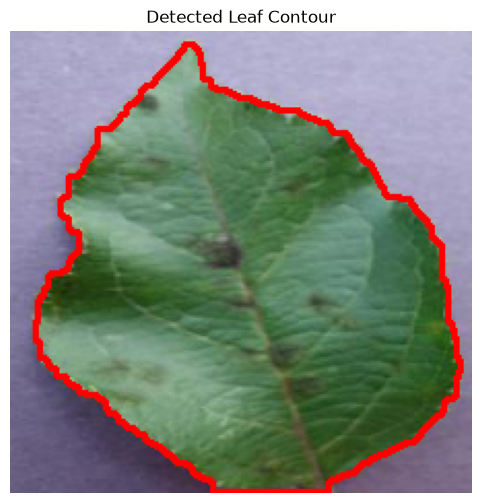

In [33]:
contour_image = resized_image.copy()

cv2.drawContours(
    contour_image,
    [largest_contour],
    -1,
    (255, 0, 0),
    2
)

plt.figure(figsize=(6, 6))
plt.imshow(contour_image)
plt.title("Detected Leaf Contour")
plt.axis("off")
plt.show()

In [34]:
x, y, w, h = cv2.boundingRect(largest_contour)

aspect_ratio = w / h if h != 0 else 0

print("Width:", w)
print("Height:", h)
print("Aspect Ratio:", round(aspect_ratio, 4))

Width: 207
Height: 218
Aspect Ratio: 0.9495


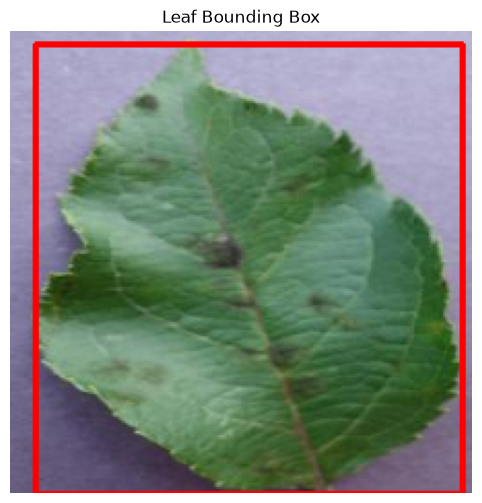

In [35]:
bbox_image = resized_image.copy()

cv2.rectangle(
    bbox_image,
    (x, y),
    (x + w, y + h),
    (255, 0, 0),
    2
)

plt.figure(figsize=(6, 6))
plt.imshow(bbox_image)
plt.title("Leaf Bounding Box")
plt.axis("off")
plt.show()

In [36]:
if leaf_perimeter != 0:
    circularity = (
        4 * np.pi * leaf_area
    ) / (leaf_perimeter ** 2)
else:
    circularity = 0

print("Circularity:", round(circularity, 4))

Circularity: 0.7002


In [37]:
image_features.update({
    "leaf_area": leaf_area,
    "leaf_perimeter": leaf_perimeter,
    "aspect_ratio": aspect_ratio,
    "circularity": circularity
})

print("Total features:", len(image_features))

image_features

Total features: 20


{'mean_r': np.float64(85.50780423280423),
 'mean_g': np.float64(121.69679232804233),
 'mean_b': np.float64(85.09494047619047),
 'std_r': np.float64(28.42690207963705),
 'std_g': np.float64(28.772631355294326),
 'std_b': np.float64(35.644674287879944),
 'mean_h': np.float64(60.08399470899471),
 'mean_s': np.float64(93.26104497354497),
 'mean_v': np.float64(121.76421957671958),
 'std_h': np.float64(10.293886968003141),
 'std_s': np.float64(34.61789786911222),
 'std_v': np.float64(28.67370534987532),
 'contrast': np.float64(166.67328635490074),
 'correlation': np.float64(0.9741944782305472),
 'energy': np.float64(0.39057657088039804),
 'homogeneity': np.float64(0.5667873723197299),
 'leaf_area': 29919.0,
 'leaf_perimeter': 732.7838319540024,
 'aspect_ratio': 0.9495412844036697,
 'circularity': 0.7001727116587885}

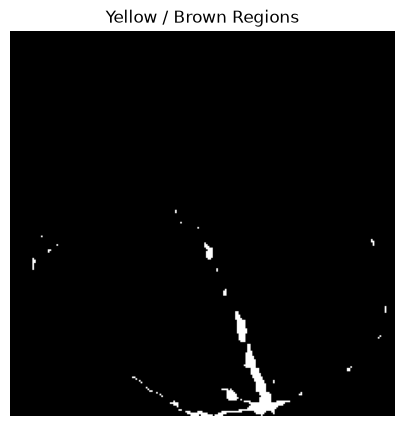

In [38]:
# HSV ranges for yellow/brown-like regions

lower_yellow = np.array([15, 40, 40])
upper_yellow = np.array([40, 255, 255])

yellow_mask = cv2.inRange(
    hsv_image,
    lower_yellow,
    upper_yellow
)

# Keep only regions inside our leaf
yellow_mask = cv2.bitwise_and(
    yellow_mask,
    clean_mask
)

plt.figure(figsize=(5, 5))
plt.imshow(yellow_mask, cmap="gray")
plt.title("Yellow / Brown Regions")
plt.axis("off")
plt.show()

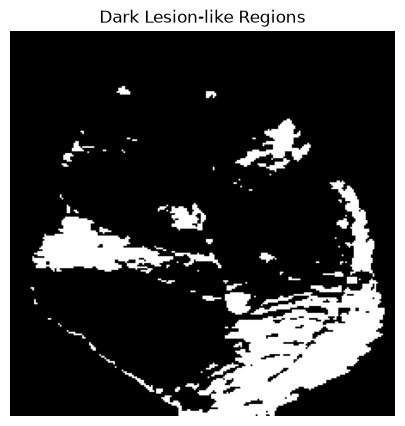

In [39]:
# Dark regions in HSV
lower_dark = np.array([0, 20, 0])
upper_dark = np.array([180, 255, 100])

dark_mask = cv2.inRange(
    hsv_image,
    lower_dark,
    upper_dark
)

dark_mask = cv2.bitwise_and(
    dark_mask,
    clean_mask
)

plt.figure(figsize=(5, 5))
plt.imshow(dark_mask, cmap="gray")
plt.title("Dark Lesion-like Regions")
plt.axis("off")
plt.show()

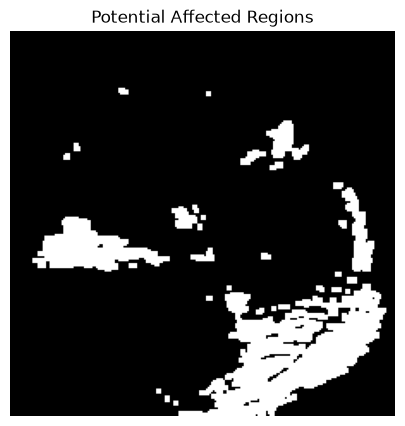

In [40]:
lesion_mask = cv2.bitwise_or(
    yellow_mask,
    dark_mask
)

# Remove small noise
kernel = np.ones((3, 3), np.uint8)

lesion_mask = cv2.morphologyEx(
    lesion_mask,
    cv2.MORPH_OPEN,
    kernel
)

plt.figure(figsize=(5, 5))
plt.imshow(lesion_mask, cmap="gray")
plt.title("Potential Affected Regions")
plt.axis("off")
plt.show()

In [41]:
leaf_pixel_count = cv2.countNonZero(clean_mask)
affected_pixel_count = cv2.countNonZero(lesion_mask)

if leaf_pixel_count > 0:
    affected_percentage = (
        affected_pixel_count / leaf_pixel_count
    ) * 100
else:
    affected_percentage = 0

print("Leaf Pixels:", leaf_pixel_count)
print("Affected Pixels:", affected_pixel_count)
print(
    "Estimated Affected Area:",
    round(affected_percentage, 2),
    "%"
)

Leaf Pixels: 30240
Affected Pixels: 6893
Estimated Affected Area: 22.79 %


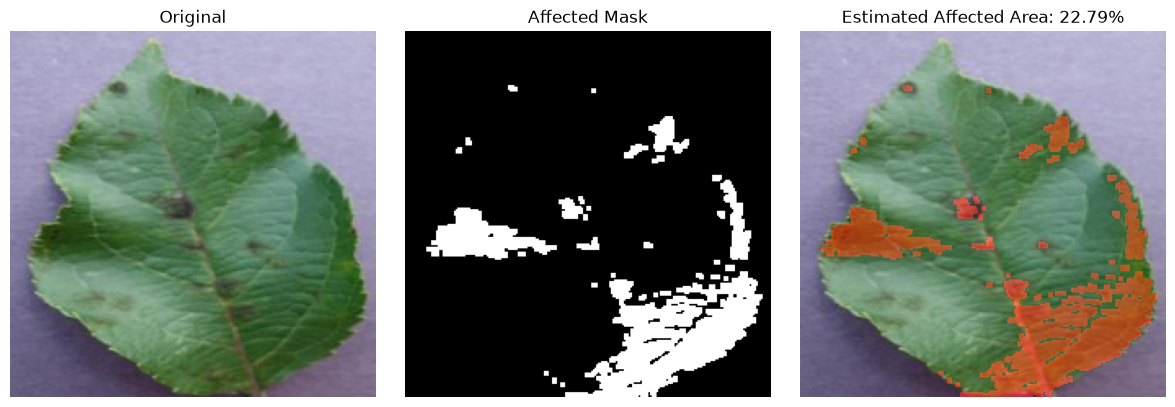

In [42]:
highlighted_image = resized_image.copy()

# Red overlay
overlay = np.zeros_like(highlighted_image)
overlay[:, :, 0] = 255

affected_overlay = cv2.bitwise_and(
    overlay,
    overlay,
    mask=lesion_mask
)

highlighted_image = cv2.addWeighted(
    highlighted_image,
    1.0,
    affected_overlay,
    0.5,
    0
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(resized_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(lesion_mask, cmap="gray")
plt.title("Affected Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(highlighted_image)
plt.title(
    f"Estimated Affected Area: "
    f"{affected_percentage:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
image_features["affected_percentage"] = affected_percentage

print("Total features:", len(image_features))

Total features: 21


In [44]:
def extract_features(image_path):

    # -----------------------------
    # 1. Read and resize image
    # -----------------------------
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(
        image_rgb,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    # -----------------------------
    # 2. Convert to HSV
    # -----------------------------
    hsv = cv2.cvtColor(resized, cv2.COLOR_RGB2HSV)

    # -----------------------------
    # 3. Leaf segmentation
    # -----------------------------
    lower_green = np.array([20, 30, 20])
    upper_green = np.array([100, 255, 255])

    mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    kernel = np.ones((5, 5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # Check that leaf was detected
    if cv2.countNonZero(mask) == 0:
        return None

    # -----------------------------
    # 4. RGB features
    # -----------------------------
    rgb_pixels = resized[mask > 0]

    mean_rgb = np.mean(rgb_pixels, axis=0)
    std_rgb = np.std(rgb_pixels, axis=0)

    # -----------------------------
    # 5. HSV features
    # -----------------------------
    hsv_pixels = hsv[mask > 0]

    mean_hsv = np.mean(hsv_pixels, axis=0)
    std_hsv = np.std(hsv_pixels, axis=0)

    # -----------------------------
    # 6. Texture features
    # -----------------------------
    gray = cv2.cvtColor(
        resized,
        cv2.COLOR_RGB2GRAY
    )

    # Crop texture calculation to the leaf bounding region
    mask_points = cv2.findNonZero(mask)

    if mask_points is None:
        return None

    bx, by, bw, bh = cv2.boundingRect(mask_points)

    gray_crop = gray[by:by+bh, bx:bx+bw]
    mask_crop = mask[by:by+bh, bx:bx+bw]

    # Quantize grayscale to 32 levels
    # Reduces GLCM size and makes extraction faster
    gray_quantized = (
        gray_crop.astype(np.float32) / 256 * 32
    ).astype(np.uint8)

    # Set background to zero
    gray_quantized[mask_crop == 0] = 0

    glcm = graycomatrix(
        gray_quantized,
        distances=[1],
        angles=[0],
        levels=32,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(
        glcm, "contrast"
    )[0, 0]

    correlation = graycoprops(
        glcm, "correlation"
    )[0, 0]

    energy = graycoprops(
        glcm, "energy"
    )[0, 0]

    homogeneity = graycoprops(
        glcm, "homogeneity"
    )[0, 0]

    # -----------------------------
    # 7. Shape features
    # -----------------------------
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    leaf_area = cv2.contourArea(
        largest_contour
    )

    leaf_perimeter = cv2.arcLength(
        largest_contour,
        True
    )

    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    aspect_ratio = (
        w / h if h > 0 else 0
    )

    circularity = (
        (4 * np.pi * leaf_area) /
        (leaf_perimeter ** 2)
        if leaf_perimeter > 0
        else 0
    )

    # -----------------------------
    # 8. Affected-area estimate
    # -----------------------------
    lower_yellow = np.array([15, 40, 40])
    upper_yellow = np.array([40, 255, 255])

    yellow_mask = cv2.inRange(
        hsv,
        lower_yellow,
        upper_yellow
    )

    yellow_mask = cv2.bitwise_and(
        yellow_mask,
        mask
    )

    lower_dark = np.array([0, 20, 0])
    upper_dark = np.array([180, 255, 100])

    dark_mask = cv2.inRange(
        hsv,
        lower_dark,
        upper_dark
    )

    dark_mask = cv2.bitwise_and(
        dark_mask,
        mask
    )

    lesion_mask = cv2.bitwise_or(
        yellow_mask,
        dark_mask
    )

    lesion_kernel = np.ones(
        (3, 3),
        np.uint8
    )

    lesion_mask = cv2.morphologyEx(
        lesion_mask,
        cv2.MORPH_OPEN,
        lesion_kernel
    )

    leaf_pixels = cv2.countNonZero(mask)
    affected_pixels = cv2.countNonZero(
        lesion_mask
    )

    affected_percentage = (
        affected_pixels / leaf_pixels * 100
        if leaf_pixels > 0
        else 0
    )

    # -----------------------------
    # 9. Return 21 features
    # -----------------------------
    return {
        "mean_r": mean_rgb[0],
        "mean_g": mean_rgb[1],
        "mean_b": mean_rgb[2],

        "std_r": std_rgb[0],
        "std_g": std_rgb[1],
        "std_b": std_rgb[2],

        "mean_h": mean_hsv[0],
        "mean_s": mean_hsv[1],
        "mean_v": mean_hsv[2],

        "std_h": std_hsv[0],
        "std_s": std_hsv[1],
        "std_v": std_hsv[2],

        "contrast": contrast,
        "correlation": correlation,
        "energy": energy,
        "homogeneity": homogeneity,

        "leaf_area": leaf_area,
        "leaf_perimeter": leaf_perimeter,
        "aspect_ratio": aspect_ratio,
        "circularity": circularity,

        "affected_percentage":
            affected_percentage
    }

In [45]:
test_path = selected_df.iloc[0]["image_path"]

test_features = extract_features(test_path)

print("Number of extracted features:", len(test_features))

test_features

Number of extracted features: 21


{'mean_r': np.float64(85.50780423280423),
 'mean_g': np.float64(121.69679232804233),
 'mean_b': np.float64(85.09494047619047),
 'std_r': np.float64(28.42690207963719),
 'std_g': np.float64(28.772631355294294),
 'std_b': np.float64(35.64467428787942),
 'mean_h': np.float64(60.08399470899471),
 'mean_s': np.float64(93.26104497354497),
 'mean_v': np.float64(121.76421957671958),
 'std_h': np.float64(10.293886968003438),
 'std_s': np.float64(34.61789786911286),
 'std_v': np.float64(28.6737053498753),
 'contrast': np.float64(2.8038434132003207),
 'correlation': np.float64(0.9692070894213034),
 'energy': np.float64(0.3439121327715653),
 'homogeneity': np.float64(0.8511151663865633),
 'leaf_area': 29919.0,
 'leaf_perimeter': 732.7838319540024,
 'aspect_ratio': 0.9495412844036697,
 'circularity': 0.7001727116587885,
 'affected_percentage': 22.79431216931217}

In [46]:
test_samples = selected_df.sample(
    10,
    random_state=42
)

for _, row in test_samples.iterrows():

    features = extract_features(
        row["image_path"]
    )

    if features is not None:

        print(
            row["class"],
            "→",
            len(features),
            "features"
        )

    else:

        print(
            row["class"],
            "→ FAILED"
        )

Corn_(maize)___Common_rust_ → 21 features
Tomato___Target_Spot → 21 features
Tomato___Septoria_leaf_spot → 21 features
Tomato___Early_blight → 21 features
Tomato___Tomato_Yellow_Leaf_Curl_Virus → 21 features
Tomato___healthy → 21 features
Corn_(maize)___healthy → 21 features
Apple___healthy → 21 features
Tomato___Tomato_mosaic_virus → 21 features
Pepper,_bell___healthy → 21 features


In [48]:
print("df columns:")
print(df.columns.tolist())

print("\nselected_df columns:")
print(selected_df.columns.tolist())

df columns:
['image_path', 'plant', 'disease', 'class']

selected_df columns:
['image_path', 'plant', 'disease', 'class']


In [49]:
selected_plants = [
    "Tomato",
    "Apple",
    "Grape",
    "Corn_(maize)",
    "Potato",
    "Pepper,_bell"
]

selected_df = df[df["plant"].isin(selected_plants)].copy()

print("Selected dataset:", len(selected_df))
print("Number of plants:", selected_df["plant"].nunique())
print("Number of classes:", selected_df["class"].nunique())

print("\nColumns:")
print(selected_df.columns.tolist())

Selected dataset: 34329
Number of plants: 6
Number of classes: 27

Columns:
['image_path', 'plant', 'disease', 'class']


In [50]:
selected_df.head()

,image_path,plant,disease,class
0,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
1,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
2,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
3,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab
4,..\data\raw\PlantVillage\color\Apple___Apple_s...,Apple,Apple_scab,Apple___Apple_scab


In [51]:
MAX_IMAGES_PER_CLASS = 500

sampled_groups = []

for class_name, group in selected_df.groupby("class"):

    n_samples = min(
        len(group),
        MAX_IMAGES_PER_CLASS
    )

    sampled_group = group.sample(
        n=n_samples,
        random_state=42
    )

    sampled_groups.append(sampled_group)

ml_sample_df = pd.concat(
    sampled_groups,
    ignore_index=True
)

print("Images selected for ML:", len(ml_sample_df))
print("Number of classes:", ml_sample_df["class"].nunique())

print("\nImages per class:")
print(ml_sample_df["class"].value_counts())

Images selected for ML: 12723
Number of classes: 27

Images per class:
class
Apple___Apple_scab                                    500
Apple___Black_rot                                     500
Apple___healthy                                       500
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    500
Corn_(maize)___Common_rust_                           500
Corn_(maize)___Northern_Leaf_Blight                   500
Corn_(maize)___healthy                                500
Grape___Black_rot                                     500
Grape___Esca_(Black_Measles)                          500
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            500
Pepper,_bell___Bacterial_spot                         500
Pepper,_bell___healthy                                500
Potato___Early_blight                                 500
Potato___Late_blight                                  500
Tomato___Bacterial_spot                               500
Tomato___Early_blight                                

In [52]:
from tqdm.auto import tqdm

feature_rows = []
failed_images = []

for _, row in tqdm(
    ml_sample_df.iterrows(),
    total=len(ml_sample_df),
    desc="Extracting PlantVision Features"
):
    
    try:
        features = extract_features(row["image_path"])

        if features is not None:

            features["plant"] = row["plant"]
            features["disease"] = row["disease"]
            features["class"] = row["class"]
            features["image_path"] = row["image_path"]

            feature_rows.append(features)

        else:
            failed_images.append(row["image_path"])

    except Exception as e:

        failed_images.append(row["image_path"])

Extracting PlantVision Features:   0%|          | 0/12723 [00:00<?, ?it/s]

In [53]:
features_df = pd.DataFrame(feature_rows)

print("Successfully processed:", len(features_df))
print("Failed images:", len(failed_images))

print("\nDataFrame shape:")
print(features_df.shape)

Successfully processed: 12722
Failed images: 1

DataFrame shape:
(12722, 25)


In [54]:
features_df.head()


,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_h,mean_s,mean_v,std_h,...,homogeneity,leaf_area,leaf_perimeter,aspect_ratio,circularity,affected_percentage,plant,disease,class,image_path
0,88.715382,104.747058,61.148910,25.658868,28.647490,27.427039,40.148757,113.321103,105.209651,7.061685,...,0.704513,19264.5,620.516807,0.696078,0.628725,52.763279,Apple,Apple_scab,Apple___Apple_scab,..\data\raw\PlantVillage\color\Apple___Apple_s...
1,109.168064,133.856366,90.442456,34.587176,32.967430,40.353422,47.257061,89.657114,134.065360,9.374063,...,0.710232,26530.5,762.859952,0.958525,0.572883,13.298595,Apple,Apple_scab,Apple___Apple_scab,..\data\raw\PlantVillage\color\Apple___Apple_s...
2,73.565505,95.840999,61.819413,19.967724,22.395090,23.888133,49.898444,96.472235,95.922153,9.273605,...,0.802692,28399.5,728.256920,1.000000,0.672901,49.239286,Apple,Apple_scab,Apple___Apple_scab,..\data\raw\PlantVillage\color\Apple___Apple_s...
3,88.441506,117.128265,67.077032,31.893995,29.684584,34.375169,47.260547,114.891895,117.286630,10.133479,...,0.734452,24305.0,749.161468,1.019417,0.544195,14.441019,Apple,Apple_scab,Apple___Apple_scab,..\data\raw\PlantVillage\color\Apple___Apple_s...
4,96.664230,130.827270,82.679281,30.707576,27.914445,35.340479,51.647086,100.758350,130.969726,7.516948,...,0.693921,34546.5,749.428493,0.958904,0.772954,8.374187,Apple,Apple_scab,Apple___Apple_scab,..\data\raw\PlantVillage\color\Apple___Apple_s...


In [55]:
print("Missing values:", features_df.isnull().sum().sum())

print(
    "Infinite values:",
    np.isinf(
        features_df.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

Missing values: 0
Infinite values: 0


In [56]:
print(
    "Classes after feature extraction:",
    features_df["class"].nunique()
)

Classes after feature extraction: 27


In [58]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\adity\OneDrive\Desktop\PlantVision-AI\notebooks


In [59]:
from pathlib import Path

OUTPUT_DIR = Path("data/processed")

# Create directory if needed
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "plantvision_features.csv"

features_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Feature dataset saved successfully!")
print("Saved at:", OUTPUT_PATH.resolve())

Feature dataset saved successfully!
Saved at: C:\Users\adity\OneDrive\Desktop\PlantVision-AI\notebooks\data\processed\plantvision_features.csv


In [60]:
print("File exists:", OUTPUT_PATH.exists())
print("Rows saved:", len(features_df))

File exists: True
Rows saved: 12722


In [61]:
# Our 21 numerical input features
feature_columns = [
    "mean_r", "mean_g", "mean_b",
    "std_r", "std_g", "std_b",
    "mean_h", "mean_s", "mean_v",
    "std_h", "std_s", "std_v",
    "contrast", "correlation",
    "energy", "homogeneity",
    "leaf_area", "leaf_perimeter",
    "aspect_ratio", "circularity",
    "affected_percentage"
]

X = features_df[feature_columns]

# Target = plant + disease class
y = features_df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", X.shape[1])
print("Number of classes:", y.nunique())

X shape: (12722, 21)
y shape: (12722,)

Number of features: 21
Number of classes: 27


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:", y_train.nunique())
print("Testing classes:", y_test.nunique())

Training samples: 10177
Testing samples: 2545

Training classes: 27
Testing classes: 27


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [64]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [65]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 74.7 %


In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.73      0.57      0.64       100
                                 Apple___Black_rot       0.77      0.66      0.71       100
                          Apple___Cedar_apple_rust       0.67      0.76      0.71        55
                                   Apple___healthy       0.84      0.71      0.77       100
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.72      0.64      0.68       100
                       Corn_(maize)___Common_rust_       0.82      0.84      0.83       100
               Corn_(maize)___Northern_Leaf_Blight       0.62      0.59      0.61       100
                            Corn_(maize)___healthy       0.95      1.00      0.98       100
                                 Grape___Black_rot       0.71      0.77      0.74       100
                      Grape___Esca_(Black_Measles)       0.84      0.79      0.

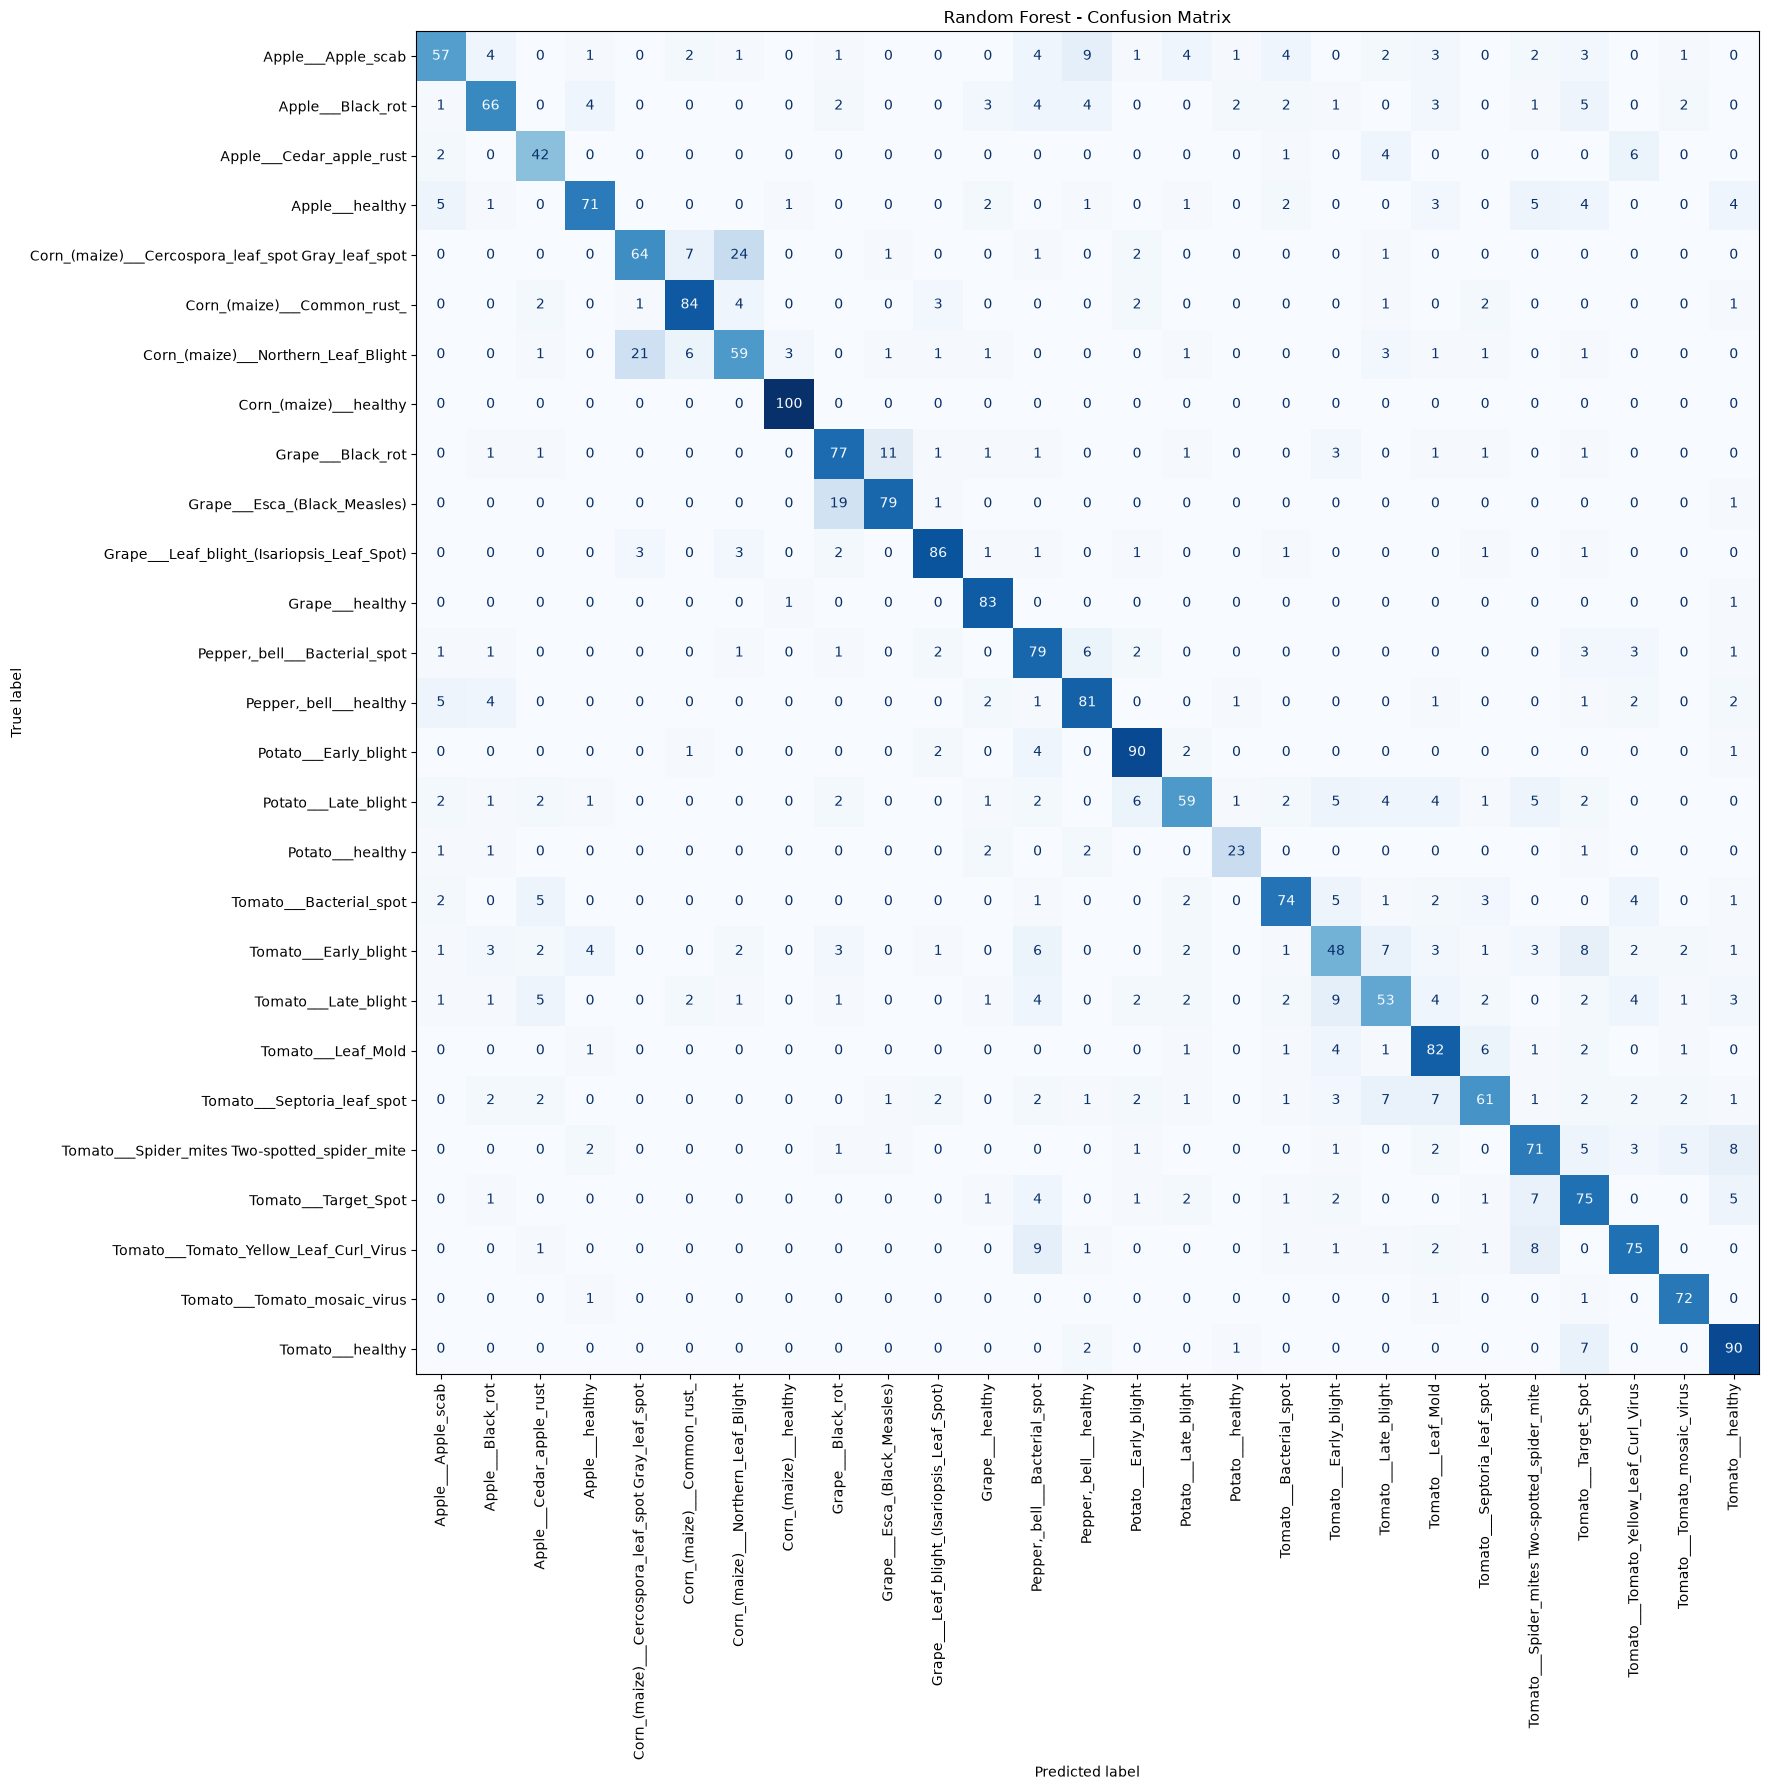

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=rf_model.classes_
)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [68]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
16,leaf_area,0.078914
6,mean_h,0.058406
9,std_h,0.058186
20,affected_percentage,0.054790
15,homogeneity,0.053496
14,energy,0.053178
7,mean_s,0.052073
17,leaf_perimeter,0.051583
12,contrast,0.049706
13,correlation,0.048575


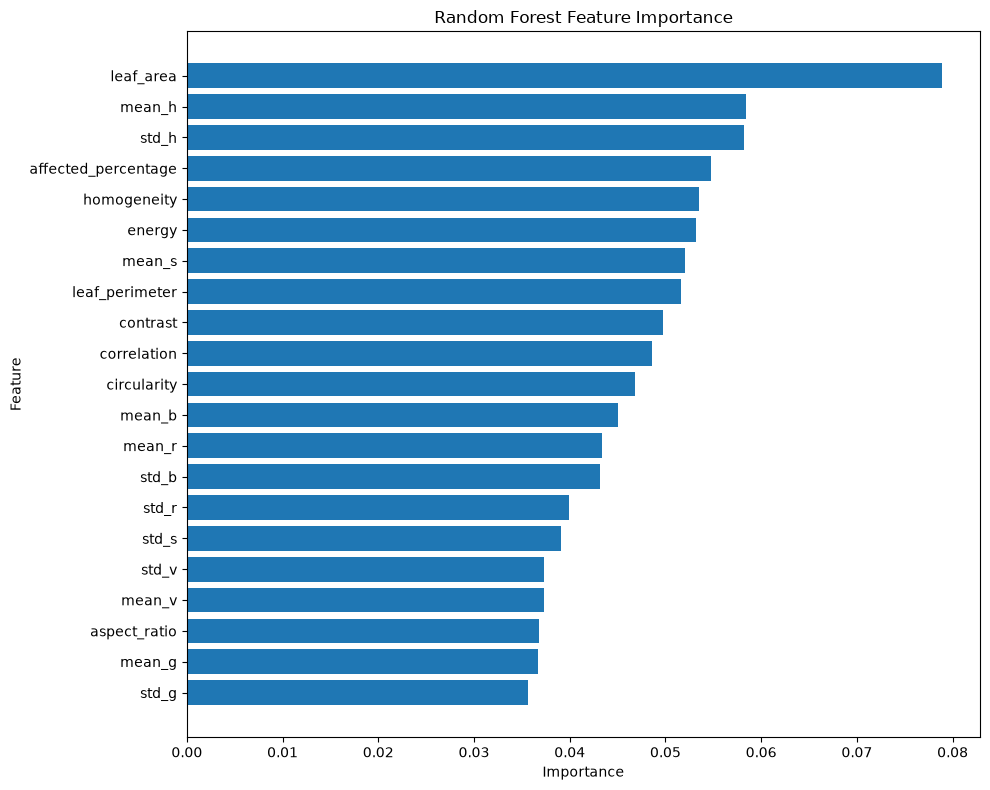

In [69]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [70]:
print("Top 10 Most Important Features:\n")

print(
    feature_importance.head(10).to_string(
        index=False
    )
)

Top 10 Most Important Features:

            Feature  Importance
          leaf_area    0.078914
             mean_h    0.058406
              std_h    0.058186
affected_percentage    0.054790
        homogeneity    0.053496
             energy    0.053178
             mean_s    0.052073
     leaf_perimeter    0.051583
           contrast    0.049706
        correlation    0.048575


In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling only from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (10177, 21)
Testing shape: (2545, 21)


In [72]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM training completed!")

SVM training completed!


In [73]:
y_pred_svm = svm_model.predict(
    X_test_scaled
)

print("SVM predictions completed!")

SVM predictions completed!


In [74]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(
    "SVM Accuracy:",
    round(svm_accuracy * 100, 2),
    "%"
)

SVM Accuracy: 83.77 %


In [75]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm,
        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.72      0.79      0.76       100
                                 Apple___Black_rot       0.85      0.82      0.84       100
                          Apple___Cedar_apple_rust       0.81      0.93      0.86        55
                                   Apple___healthy       0.93      0.83      0.88       100
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.78      0.80       100
                       Corn_(maize)___Common_rust_       0.94      0.87      0.90       100
               Corn_(maize)___Northern_Leaf_Blight       0.77      0.79      0.78       100
                            Corn_(maize)___healthy       1.00      1.00      1.00       100
                                 Grape___Black_rot       0.85      0.82      0.83       100
                      Grape___Esca_(Black_Measles)       0.90      0.88      0.

In [76]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        rf_accuracy,
        svm_accuracy
    ]
})

comparison_df["Accuracy (%)"] = (
    comparison_df["Accuracy"] * 100
).round(2)

comparison_df

,Model,Accuracy,Accuracy (%)
0,Random Forest,0.746955,74.70
1,SVM,0.837721,83.77


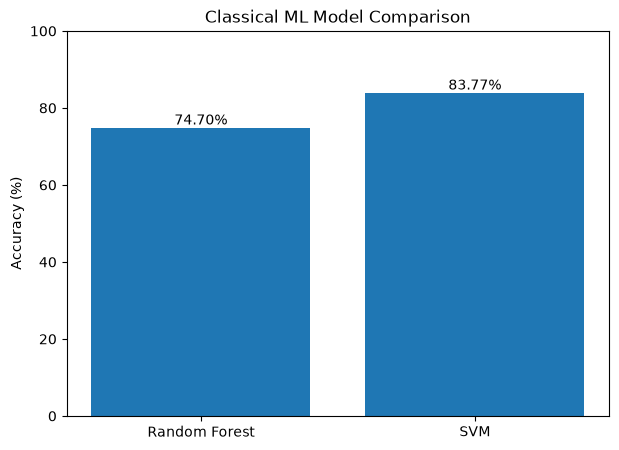

In [77]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.title("Classical ML Model Comparison")
plt.ylim(0, 100)

for i, value in enumerate(comparison_df["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [78]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest.pkl"
)

joblib.dump(
    svm_model,
    MODEL_DIR / "svm.pkl"
)

joblib.dump(
    scaler,
    MODEL_DIR / "scaler.pkl"
)

joblib.dump(
    feature_columns,
    MODEL_DIR / "feature_columns.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [79]:
import sys

print(sys.version)
print(sys.executable)

3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]
c:\Users\adity\OneDrive\Desktop\PlantVision-AI\.venv\Scripts\python.exe
